In [ ]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn import metrics

from sklearn.metrics import confusion_matrix, average_precision_score, PrecisionRecallDisplay
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

In [38]:
# Loading in Credit Card Fraud Dataset

cc_fraud_url = ('creditcard.csv')

cc_fraud_data = pd.read_csv(cc_fraud_url)
print(f'Dataset shape: {cc_fraud_data.shape}')

cc_fraud_data.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [39]:
# Exploring the dataset
cc_fraud_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [40]:
cc_fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [41]:
# Checking for missing values
print(cc_fraud_data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [42]:
# Cleaning and preparing data by separating features and target variable, where the target variable is 'Class' (1 for fraud, 0 for non-fraud)
X = cc_fraud_data.drop('Class', axis = 1).copy() # this is a copy of the original dataset without the 'Class' column so that it can be manipulated without
# affecting the original dataset.
y = cc_fraud_data['Class']

In [43]:
# Calculating class prevalence (According to https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download, where this dataset is from, the dataset is highly imbalanced with only 0.172% of transactions being fraudulent.
# However, we still want to calculate the class prevalence to confirm this and have a better understanding of the dataset.)
prevalence = y.value_counts(normalize = True)
print(f'Class prevalence: \n{prevalence}')

Class prevalence: 
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [44]:
# This would normally be where we would collapse factor levels, but since there are no categorical variables in this dataset, we can skip this step 
# and move on to splitting the data into training and testing sets. We used an 80-20 split for the training and testing sets, respectively. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y) # Stratifying by the target variable y 
# is crucial because it ensures that the class distribution in the training and testing sets is similar to the original dataset. This is especially 
# important because the dataset is so imbalanced, and stratifying helps to prevent the model from being biased towards the majority class (non-fraudulent transactions)
# and allows it to learn from the minority class (fradulent transactions) as well.

## Model 5: ExtraTreesClassifier Pipeline
We used an ExtraTreesClassifier because it combines the predictions of multiple decision trees to achieve its output, which helps to reduce the risk of overfitting and improve performance beyond that of a regular Decision Tree.

In [45]:
et_pipeline = Pipeline([
    ('classifier', ExtraTreesClassifier(
        n_estimators = 100,
        class_weight = 'balanced', # Having balanced class weights is important because the dataset is extremely imbalanced, 
        # and this helps to prevent the model from being biased towards the majority class.
        random_state = 42,
        n_jobs = -1 # Using all available cores for parallel processing to speed up training, especially since the dataset is large and the model is complex.
        ))
])

In [46]:
# Fitting the model to the training data
et_pipeline.fit(X_train, y_train)

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [47]:
# Predicting on the test set is important to evaluate the model's performance on unseen data and to get an estimate of how well the model generalizes to new data.
et_pred = et_pipeline.predict(X_test)
et_prob = et_pipeline.predict_proba(X_test) # Getting the predicted probabilities for the positive class (fraudulent transactions) to use for evaluation metrics 
# that require probabilties, such as average precision score and precision-recall curve.

In [48]:
# Results DataFrame to compare the true labels, predicted labels, and predicted probabilities for the test set. This will be useful for
# evaluating the model's performance and for creating vis
results_df = pd.DataFrame({
    'Target': y_test,
    'Predicted': et_pred,
    'Predicted_Prob_Legitimate': et_prob[:, 0],
    'Predicted_Prob_Fraudulent': et_prob[:, 1]
})

print(results_df.head())

        Target  Predicted  Predicted_Prob_Legitimate  \
263020       0          0                       1.00   
11378        0          0                       1.00   
147283       0          0                       0.98   
219439       0          0                       1.00   
36939        0          0                       1.00   

        Predicted_Prob_Fraudulent  
263020                       0.00  
11378                        0.00  
147283                       0.02  
219439                       0.00  
36939                        0.00  


The results above reflect that the model is predicting the majority class (non-fraudulent transactions) much more often than the minority class (fraudulent transactions), which is expected given the extreme class imbalance in the dataset. Therefore, we took additional steps to evaluate the model's performance using metrics that are more appropriate for imbalanced datasets, such as the average precision score and the precision-recall curve, which focus on the performance of the model in identifying the minority class (fraudulent transactions) rather than being influenced by the majority class (non-fraudulent transactions).

In [49]:
# Evaluating the model's performance using the fraud class as the positive class
y_true_binary = results_df['Target']

In [50]:
# ROC AUC Score & PR AUC Score are both important metrics for evaluating the performance of this model because they take the predicted
# probabilities into account, which is crucial for datasets biased towards one class. They provide a more comprehensive evaluation of the model's
# ability to distinguish between the classes, crucial in navigating the accuracy's limitations due to class imbalance.
roc_auc = metrics.roc_auc_score(y_true_binary, results_df['Predicted_Prob_Fraudulent'])
print(f'ROC AUC Score: {roc_auc:.4f}')

pr_auc = average_precision_score(y_true_binary, results_df['Predicted_Prob_Fraudulent'])
print(f'PR AUC Score: {pr_auc:.4f}')

ROC AUC Score: 0.9528
PR AUC Score: 0.8758


Text(0.5, 1.0, 'Precision-Recall Curve for ExtraTreesClassifier')

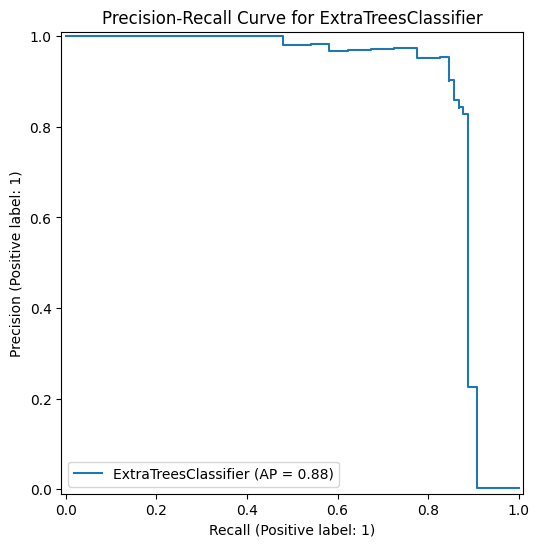

In [51]:
# To visualize these results, we created a precision-recall curve to show the tradeoff between precision and recall at different thresholds for the
# predicted probabilities of fraudulent transactions.

fig, ax = plt.subplots(figsize = (8, 6))
PrecisionRecallDisplay.from_predictions(
    y_true_binary,
    results_df['Predicted_Prob_Fraudulent'],
    ax = ax,
    name = 'ExtraTreesClassifier'
)
ax.set_title('Precision-Recall Curve for ExtraTreesClassifier')


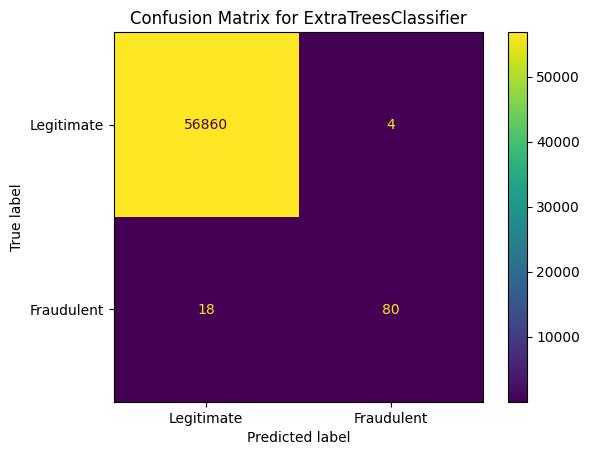

In [52]:
# Lastly, we created a confusion matrix to show the number of true positives, true negatives, false positives, and false negatives for the model's 
# predictions on the test set. This is important to understand the types of errors the model is making and to evaluate its performance in more
# detail than just looking at the overall metrics.
cm = confusion_matrix(y_true_binary, results_df['Predicted'])
metrics.ConfusionMatrixDisplay.from_predictions(
    results_df['Target'],
    results_df['Predicted'],
    display_labels = ['Legitimate', 'Fraudulent']
)
plt.title('Confusion Matrix for ExtraTreesClassifier')
plt.show()

The results above reflect that the model's ability to distinguish between fraudulent and legitimate transactions is very promising, with a ROC AUC Score of 0.9528 and a PR AUC Score of 0.8758. The high ROC AUC Score indicates that the model has a strong ability to differentiate between the two classes across all classification thresholds, while the high PR AUC Score suggests that the model maintains a good balance between precision and recall. These results are particularly reassuring given how few fraudulent transactions there are in the dataset, and show that the model can effectively identify fraudulent transactions without being overwhelmed by the majority class of legitimate transactions.

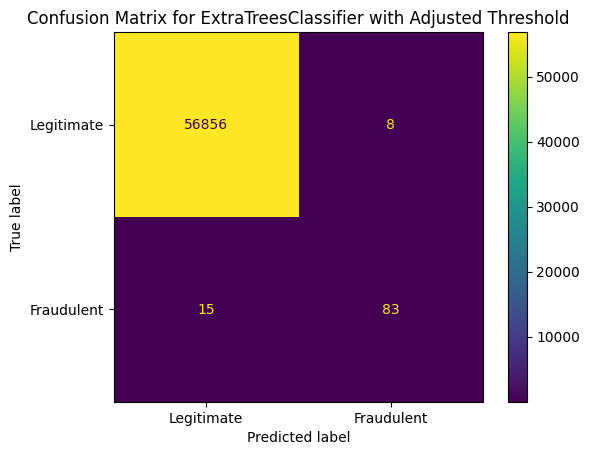

In [56]:
# Missed fraud cases (false negatives) are particularly concerning in this context because they represent fraudulent transactions that the model 
# failed to identify, resulting in potential financial losses for the cardholders. Therefore, minimizing false negatives is crucial in fraud 
# detection to protect these customers and minimize the financial impact of fraud.

# To see if we can improve the model's performance, we tried reducing the threshold for classifying a transaction as fraudulent from the default 
# 0.5 to 0.3 based on the results of the PR curve, which showed that the model had a better balance of precision and recall at this threshold.
# This is important because it allows us to find a better balance between precision and recall, which is crucial in this context where we want 
# to minimize false negatives.
threshold = 0.3
results_df['Predicted_Adjusted'] = (results_df['Predicted_Prob_Fraudulent'] >= threshold).astype(int)

# Recreation of the confusion matrix with the adjusted threshold to see how it affects the number of false negatives and false positives.
cm_adjusted = confusion_matrix(results_df['Target'], results_df['Predicted_Adjusted'])
metrics.ConfusionMatrixDisplay.from_predictions(
    results_df['Target'],
    results_df['Predicted_Adjusted'],
    display_labels = ['Legitimate', 'Fraudulent']
)
plt.title('Confusion Matrix for ExtraTreesClassifier with Adjusted Threshold')
plt.show()

Adjusting the threshold proved to reduce the amount of false negatives that the model caught. While there were slightly more false positives caught, this was an expected tradeoff of lowering the threshold and is not very concerning when considering that the model caught over 55,000 legitimate transactions correctly. Lowering the false negative predictions to 0 would likely be impossible for this model because their predicted probabilities of being fraudulent are so low that they are comparable to those of legitimate transactions. Having a threshold lower than 3 would cause a concerning amount of false positives and indicate data leakage.

# Model 6: RandomForestClassifier
We used a RandomForestClassifier in our final model because it uses optimal split selection, which has the potential to improve our accuracy.

In [97]:
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        n_estimators = 100, # Using more trees in the Random Forest to help improve model's performance, especially because of the large size
        # of the dataset and complexity of the model
        max_depth = None, # Setting this to None to allow trees to grow until all leaves are pure or contain less than the minimum numnber of
        # samples required to split an internal node to further improve model performance
        class_weight = {0: 1, 1: 10}, # Using a custom class weight to give more imporance to the fraudulent class
        random_state = 42
        ))
])

In [98]:
# Fitting the Random Forest model to the training data
rf_pipeline.fit(X_train, y_train)

# Predicting on the test set is important to evaluate the model's performance on unseen data and to get an estimate of how well the model generalizes to new data.
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test) # Getting the predicted probabilities for the positive class (fraudulent transactions) to use for evaluation metrics 
# that require probabilties, such as average precision score and precision-recall curve.

In [99]:
# Cross validation on the Random Forest model to find the best hyperparameters for the model (important to do this before fitting the model to the
# training data to ensure that we are using the best hyperparameters for the model to avoid overfitting the training data and improve performance
# on the test set).

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42) # StratifiedKFold is used to ensure that the class distribution in each fold is
# similar to the original dataset, which is important to prevent the model from being biased towards the majority class.

rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train, y_train,
    cv = cv,
    scoring = 'average_precision', # Using average precision as the scoring metric because it takes the predicted probabilities into account
    n_jobs = -1 # Using all available cores for parallel processing to speed up cross validation
    )

print(f'Random Forest Cross-Validation Precision-Recall AUC Scores: {rf_cv_scores}')
print(f'Individual Fold Scores: {rf_cv_scores}')

Random Forest Cross-Validation Precision-Recall AUC Scores: [0.86599886 0.81367253 0.82019845 0.89275165 0.82691919]
Individual Fold Scores: [0.86599886 0.81367253 0.82019845 0.89275165 0.82691919]


In [101]:
# Results DataFrame edited to show the results for the RandomForestClassifier instead of the ExtraTreesClassifier.
results_df = pd.DataFrame({
    'Target': y_test.values, # Using .values to ensure that the Target column is a numpy array, which is necessary for the evaluation metrics to
    # work correctly
    'Predicted': rf_pred,
    'Predicted_Prob_Legitimate': rf_prob[:, 0],
    'Predicted_Prob_Fraudulent': rf_prob[:, 1]
})

print(results_df.head())

   Target  Predicted  Predicted_Prob_Legitimate  Predicted_Prob_Fraudulent
0       0          0                       1.00                       0.00
1       0          0                       1.00                       0.00
2       0          0                       0.99                       0.01
3       0          0                       1.00                       0.00
4       0          0                       1.00                       0.00


In [102]:
# Evaluating the model's performance again using the fraud class as the positive class (for RandomForestClassifier)
y_true_binary = results_df['Target']

In [103]:
# ROC AUC Score & PR AUC Score are both important metrics for evaluating the performance of this model because they take the predicted
# probabilities into account, which is crucial for datasets biased towards one class. They provide a more comprehensive evaluation of the model's
# ability to distinguish between the classes, crucial in navigating the accuracy's limitations due to class imbalance.
roc_auc = metrics.roc_auc_score(y_true_binary, results_df['Predicted_Prob_Fraudulent'])
print(f'ROC AUC Score: {roc_auc:.4f}')

pr_auc = average_precision_score(y_true_binary, results_df['Predicted_Prob_Fraudulent'])
print(f'PR AUC Score: {pr_auc:.4f}')

ROC AUC Score: 0.9528
PR AUC Score: 0.8653


Text(0.5, 1.0, 'Precision-Recall Curve for RandomForestClassifier')

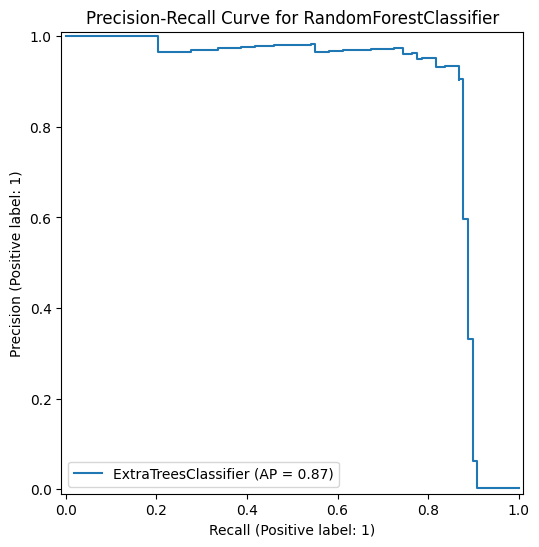

In [104]:
# Same logic to display PR curve for the RandomForestClassifier to compare it to the ExtraTreesClassifier

fig, ax = plt.subplots(figsize = (8, 6))
PrecisionRecallDisplay.from_predictions(
    y_true_binary,
    results_df['Predicted_Prob_Fraudulent'],
    ax = ax,
    name = 'ExtraTreesClassifier'
)
ax.set_title('Precision-Recall Curve for RandomForestClassifier')


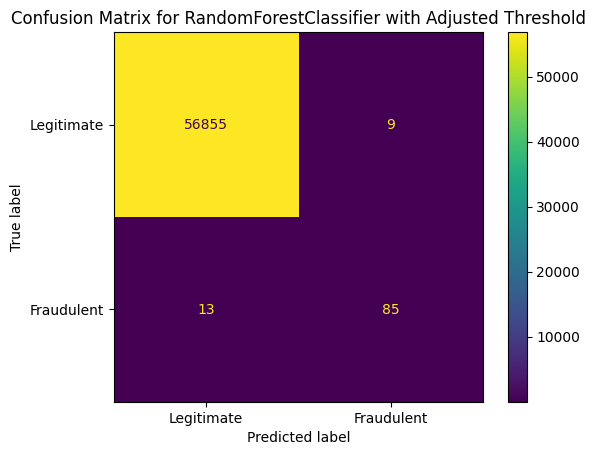

In [ ]:
# Due to its usefulness in Model 5 and almost identical results in PR curves, we kept the threshold at 0.3 in the Model 6 confusion matrix.
threshold = 0.3
results_df['Predicted_Adjusted'] = (results_df['Predicted_Prob_Fraudulent'] >= threshold).astype(int)

cm_rf = confusion_matrix(results_df['Target'], results_df['Predicted_Adjusted'])
metrics.ConfusionMatrixDisplay.from_predictions(
    results_df['Target'],
    results_df['Predicted_Adjusted'],
    display_labels = ['Legitimate', 'Fraudulent']
)
plt.title('Confusion Matrix for RandomForestClassifier with Adjusted Threshold')
plt.show()

Based on the results of Model 6's PR curve and confusion matrix, we decided that the ExtraTreesClassifier was the better model compared to a RandomForestClassifier after all. This is because while the RandomForestClassifier caught two less false negatives, it caught one more false alarm than Model 5 and its PR AUC score (0.87) is slightlty lower than that of Model 5 (0.88). The RandomForestClassifier also took significantly more time to fit to data and complete cross-validation; therefore, the ExtraTreesClassifier is not only more accurate but more efficient.